In [13]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

In [15]:
# Load dataset (top 10,000 most frequent words)
num_words = 10000
(X_train, y_train), (X_test, y_test) = keras.datasets.imdb.load_data(num_words=num_words)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 25000
Testing samples: 25000


In [16]:
print("Sample review (encoded):", X_train[0])
print("Label:", y_train[0]) # 1 = positive, 0 = negative

Sample review (encoded): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]
Label: 1


In [21]:
# Make all reviews same length
maxlen = 200
X_train = keras.preprocessing.sequence.pad_sequences(X_train, maxlen=maxlen)
X_test = keras.preprocessing.sequence.pad_sequences(X_test, maxlen=maxlen)

In [22]:
model = keras.Sequential([
layers.Embedding(input_dim=num_words, output_dim=128, input_length=maxlen),
layers.Flatten(),
layers.Dense(64, activation='relu'),
layers.Dense(32, activation='relu'),
layers.Dense(1, activation='sigmoid') # Binary classification
])

In [23]:
model.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy']
)

In [24]:
history = model.fit(
X_train, y_train,
epochs=5,
batch_size=32,
validation_split=0.2,
verbose=1
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.7004 - loss: 0.5307 - val_accuracy: 0.8530 - val_loss: 0.3385
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.9744 - loss: 0.0785 - val_accuracy: 0.8352 - val_loss: 0.5112
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.9961 - loss: 0.0135 - val_accuracy: 0.8452 - val_loss: 0.6905
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.9984 - loss: 0.0058 - val_accuracy: 0.8468 - val_loss: 0.8216
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.9954 - loss: 0.0142 - val_accuracy: 0.8458 - val_loss: 0.7409


In [25]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8312 - loss: 0.7827
Test Loss: 0.78507000207901
Test Accuracy: 0.8342400193214417


In [26]:
predictions = model.predict(X_test)
# Convert probabilities to binary output
predicted_labels = (predictions > 0.5).astype(int)
print("Predicted:", predicted_labels[:10].flatten())
print("Actual:", y_test[:10])

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
Predicted: [0 1 0 0 1 1 1 0 1 1]
Actual: [0 1 1 0 1 1 1 0 0 1]


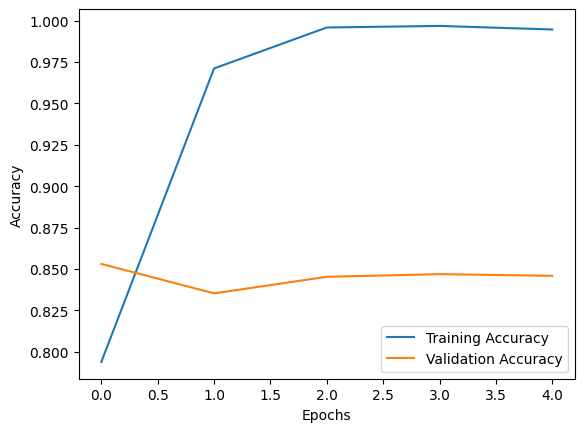

In [27]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()